# NOE (Liovillie space and Lindblad)
## Author: Vineeth Francis Thalakottoor, vineeth.thalakottoor@ens.psl.eu or vineethfrancis.physics@gmail.com
- Nuclear Overhauser effect 
- In Liovillie Space
- Lindblad Master equation

In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/Simulators/PyOR-main"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib ipympl

# Import PyOR package
from PyOR import *


*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineethfrancis.physics@gmail.com

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QunS                   (QuantumSystem from PyOR_QuantumSystem)
	** Hamiltonian         (from PyOR_Hamiltonian)
	** DensityMatrix       (from PyOR_DensityMatrix)
	** HardPulse           (from PyOR_HardPulse)
	** Basis               (from PyOR_Basis)
	** RelaxationProcess   (from PyOR_Relaxation)
	** Evolutions          (from PyOR_Evolution)
	** Plotting            (from PyOR_Plotting)
	** Spro                (from PyOR_SignalProcessing)
* QunObj                 (from PyOR_QuantumObject)
* QuantumLibrary         (from PyOR_QuantumLibrary)

How to start? Make a spin list like, Spin_list = {"A" : "H1", "B" : "H

In [2]:
# Define the spin system
Spin_list = {"A" : "H1", "B" : "H1"}
QS = QunS(Spin_list,PrintDefault=False)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix


### Set parameters

In [ ]:
# New way
QS.Configure(
    # System
    PropagationSpace="Liouville",
    MasterEquation="Lindblad",

    # Field
    B0=9.4,
    OFFSET={"A": 10.0, "B": 50.0},

    # Coupling
    Jcouplings=[("A", "B", 5.0)],
    Dipole_Pairs=[("A", "B")],

    # Temperature
    I_spintemp={"A": 300.0, "B": 300.0},
    F_spintemp={"A": 300.0, "B": 300.0},
    Lindblad_Temp=300.0,

    # Relaxation
    Rprocess="Auto-correlated Dipolar Homonuclear",
    RelaxParDipole_tau=10.0e-12,
    RelaxParDipole_bIS=[30.0e3],

    # Evolution parameters
    AcqDT = 0.0001,
    AcqAQ = 30.0,
    OdeMethod = 'DOP853',
    PropagationMethod = "Relaxation Lindblad"    
)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-2514706800.0, -2514706800.0] from {'A': -2514706800.0, 'B': -2514706800.0}
Offset    <- OFFSET    : [10.0, 50.0] from {'A': 10.0, 'B': 50.0}
Ispintemp <- I_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
Fspintemp <- F_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [-400.22802765 -400.22806765]
Larmor Frequency in MHz:  [-400.22802765 -400.22806765]
Larmor Frequency in MHz:  [-400.22802765 -400.22806765]


'\n# Master Equation\nQS.PropagationSpace = "Liouville"\nQS.MasterEquation = "Lindblad"\n\n# B0 Field in Tesla, Static Magnetic field (B0) along Z\nQS.B0 = 9.4\n\n# Offset Frequency in rotating frame (Hz)\nQS.OFFSET["A"] = 10.0\nQS.OFFSET["B"] = 50.0\n\n# Define J coupling between Spins \nQS.JcoupleValue("A","B",5.0)\n\n# Define paris of spins coupled by dipolar interaction\nQS.Dipole_Pairs = [("A","B")]\n\n# Define initial and final Spin Temperature\nQS.I_spintemp["A"] = 300.0\nQS.I_spintemp["B"] = 300.0\nQS.F_spintemp["A"] = 300.0\nQS.F_spintemp["B"] = 300.0\nQS.Lindblad_Temp = 300.0\n\n# Relaxation Process\nQS.Rprocess = "Auto-correlated Dipolar Homonuclear"\nQS.RelaxParDipole_tau = 10.0e-12\nQS.RelaxParDipole_bIS = [30.0e3]\n\nQS.RowColOrder = \'C\'\n\nQS.Update()\n'

### Generate Hamiltonians

In [4]:


Hz = QS.Hamiltonian.Zeeman_RotFrame()

# J coupling Hamiltonian
Hj = QS.Hamiltonian.Jcoupling()

# Generating the commutation superoperator

#QLib = QuantumLibrary(QS)

Hz_L = QS.QuantumLibrary.CommutationSuperoperator(Hz+Hj)

### product operator basis (Shift Z or PMZ basis)

In [5]:
BS = Basis(QS)

sort = 'negative to positive'
Index = False
Normal = True
Basis_PMZ, coh_PMZ, dic_PMZ = BS.ProductOperators_SpinHalf_PMZ(sort,Index,Normal)

### Initialize Density Matrix

In [6]:
Thermal_DensMatrix = True

if Thermal_DensMatrix:    
    # High Temperature
    HT_approx = True
    
    # Initial Density Matrix
    rho_in_L = QS.DensityMatrix.EquilibriumDensityMatrix(QS.Ispintemp,HT_approx)
    
    # Equlibrium Density Matrix
    rhoeq_L = QS.DensityMatrix.EquilibriumDensityMatrix(QS.Fspintemp,HT_approx)
else:
    rho_in = QS.Az + QS.Bz
    rhoeq = QS.Az + QS.Bz   

Trace of density matrix =  1.0
Trace of density matrix =  1.0


In [7]:
QS.DensityMatrix.DensityMatrix_Components(rho_in_L,Basis_PMZ,dic_PMZ)

Density Matrix = 2e-05 Iz1 Id2  + 2e-05 Id1 Iz2  + 0.5 Id1 Id2 


### Pulse

In [8]:
flip_angle1 = 0.0   # Flip angle Spin 1
flip_angle2 = 180.0 # Flip angle Spin 2

rho = QS.HardPulse.Rotate_Pulse(rho_in_L,flip_angle1,QS.Ay)
rho = QS.HardPulse.Rotate_Pulse(rho,flip_angle2,QS.By)

In [9]:
QS.DensityMatrix.DensityMatrix_Components(rho,Basis_PMZ,dic_PMZ)

Density Matrix = 2e-05 Iz1 Id2  + -2e-05 Id1 Iz2  + 0.5 Id1 Id2 


## Evolution 

In [10]:
# Relaxation Superoperator
R_L = QS.RelaxationProcess.Relaxation()

start_time = time.time()
t, rho_t = QS.Evolutions.Evolution(rho,rhoeq_L,Hz_L,R_L)
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Total time = 1.133319616317749 seconds 


In [11]:
R_L.matrix

Matrix([
[  0.159576453803091,                  0,                  0,                 0,                  0, -0.0266319436050379, -0.0266319436050379,                  0,                  0, -0.0266319436050379, -0.0266319436050379,                  0,                 0,                  0,                  0,  -0.106329591705398],
[                  0,  0.150832537765222, 0.0621616669026959,                 0,                  0,                   0,                   0, 0.0266319436050379,                  0,                   0,                   0, 0.0266319436050379,                 0,                  0,                  0,                   0],
[                  0, 0.0621616669026959,  0.150832537765222,                 0,                  0,                   0,                   0, 0.0266319436050379,                  0,                   0,                   0, 0.0266319436050379,                 0,                  0,                  0,                   0],
[            

### Expectation Value

In [12]:
det_Z1 = QS.Az_vec
det_Z2 = QS.Bz_vec

t, signal_Z1 = QS.Evolutions.Expectation(rho_t,det_Z1)
t, signal_Z2 = QS.Evolutions.Expectation(rho_t,det_Z2)

In [13]:
MoA = rho_in_L.Expectation(QS.Az_vec)
MoB = rho_in_L.Expectation(QS.Bz_vec)

## Plotting

/home/vineeth/anaconda3/envs/pyor/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/anaconda3/envs/pyor/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


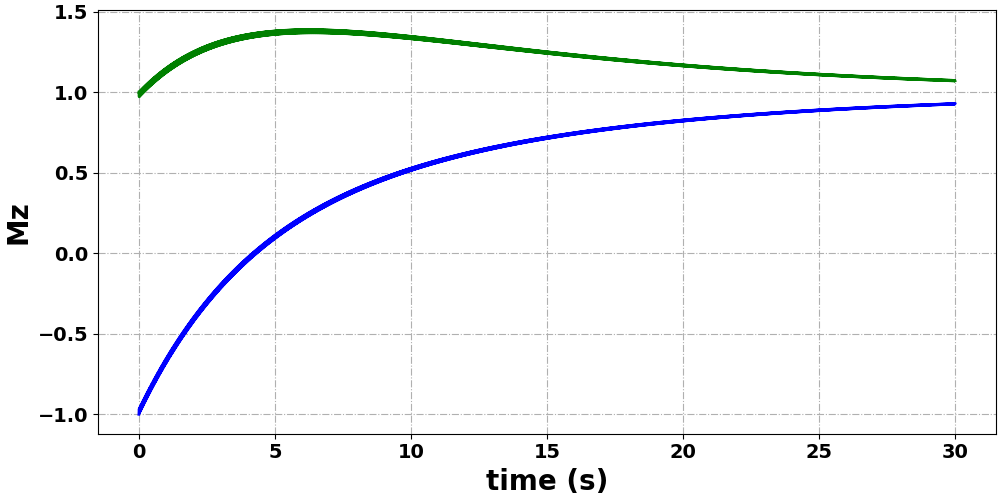

In [14]:
QS.Plotting.PlotFigureSize = (10,5)
QS.Plotting.PlotFontSize = 20
QS.Plotting.PlottingMulti([t,t],[signal_Z1/MoA,signal_Z2/MoB],"time (s)","Mz",["green","blue"])

In [15]:
QLib = QuantumLibrary(QS)